# Task : 1 Notebook Structure & Data Loading 

# 📦 E-Commerce Logistics & Delivery Data Analysis

## 📌 Project Objective
The objective of this project is to analyze an e-commerce logistics dataset to understand
delivery performance, delays, order priority impact, customer ratings, and operational efficiency.

## 📂 Dataset Information
- Dataset Name: E-commerce Logistics and Delivery Dataset
- Source: Provided CSV file
- Records: 909712 rows

## 🛠 Tools & Libraries Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn


### Import requrired Libraries :

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")


### Load dataset

In [3]:
import pandas as pd

try:
    df = pd.read_csv("Ecommerce_Logistics_and_Delivery_Gigantic.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path.")


Dataset loaded successfully.


#### Dataset Shape : 

In [4]:
df.shape

(73500, 10)

#### First & last 5 row 

In [7]:
# Display the first 5 rows of the dataset to understand the structure,
# column names, and sample values
df.head()


,Shipment_ID,Order_Date,Region,City,Delivery_Partner,Shipping_Mode,Delivery_Time_Days,Order_Value,Delivery_Status,Customer_Rating
0,900000,05-09-2022,North,Ahmedabad,Ecom Express,Standard,8.0,171575.41,Delivered,4.0
1,900001,29-03-2023,West,Ahmedabad,BlueDart,Standard,10.0,8628.10,Delayed,3.0
2,900002,23-03-2022,South,Hyderabad,BlueDart,Standard,12.0,161353.25,Cancelled,3.0
3,900003,25-01-2024,West,Hyderabad,Ecom Express,Standard,14.0,57509.48,Delayed,2.0
4,900004,11-11-2023,South,Mumbai,Ecom Express,Standard,14.0,154628.04,Delivered,1.0


In [10]:
# Display the last 5 rows of the dataset to check ending records,
# data consistency, and confirm successful data loading
df.tail()

,Shipment_ID,Order_Date,Region,City,Delivery_Partner,Shipping_Mode,Delivery_Time_Days,Order_Value,Delivery_Status,Customer_Rating
73495,901870,09-08-2022,East,Kolkata,Ecom Express,Express,7.0,7879.04,Delivered,4.0
73496,915961,20-07-2023,West,Pune,Delhivery,Express,6.0,145610.57,Delivered,3.0
73497,909351,17-09-2023,South,Mumbai,Ecom Express,Express,14.0,140215.59,Delivered,3.0
73498,966364,20-10-2021,Central,Pune,BlueDart,Same-Day,8.0,132471.00,Delayed,5.0
73499,909712,27-03-2022,NaN,NaN,NaN,Standard,13.0,37043.44,Delivered,4.0


#### Information of dataset : 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73500 entries, 0 to 73499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Shipment_ID         73500 non-null  int64  
 1   Order_Date          73500 non-null  object 
 2   Region              58743 non-null  object 
 3   City                65245 non-null  object 
 4   Delivery_Partner    65962 non-null  object 
 5   Shipping_Mode       73500 non-null  object 
 6   Delivery_Time_Days  68652 non-null  float64
 7   Order_Value         73500 non-null  float64
 8   Delivery_Status     69884 non-null  object 
 9   Customer_Rating     66117 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 5.6+ MB


#### Describe of data : 

In [12]:
# Generate descriptive statistics for numerical columns such as
# count, mean, standard deviation, minimum, and maximum values
df.describe()

,Shipment_ID,Delivery_Time_Days,Order_Value,Customer_Rating
count,73500.000000,68652.000000,73500.000000,66117.000000
mean,935016.716612,7.541761,99924.325369,3.349577
std,20199.507118,4.041246,57650.901131,1.165733
min,900000.000000,1.000000,302.070000,1.000000
25%,917524.750000,4.000000,49895.900000,3.000000
50%,935034.500000,8.000000,99908.880000,3.000000
75%,952495.250000,11.000000,149806.210000,4.000000
max,969999.000000,14.000000,199999.600000,5.000000


### 🔍 Initial Observations
- The dataset contains both numerical and categorical features.
- Some columns have missing values.
- Delivery-related columns will be crucial for performance analysis.


# Task : 2 Data Cleaning & EDA

### Identify and Handling missing Value 

In [13]:
df.isnull().sum()

Shipment_ID               0
Order_Date                0
Region                14757
City                   8255
Delivery_Partner       7538
Shipping_Mode             0
Delivery_Time_Days     4848
Order_Value               0
Delivery_Status        3616
Customer_Rating        7383
dtype: int64

###  Data Cleaning 

In [14]:
# numerical columns 
num_cols = ['Delivery_Time_Days','Customer_Rating']
for col in num_cols : 
    df[col] = df[col].fillna(df[col].mean()) 

# categorical columns 
cat_cols = ['Region','City','Delivery_Partner','Delivery_Status']
for col in cat_cols : 
    df[col] = df[col].fillna(df[col].mode()[0])

how to handling missing value in data column using pandas?
df['Order_Date'].fillna(method='ffill')

Object `pandas` not found.


C:\Users\aisam\AppData\Local\Temp\ipykernel_11500\200764979.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Order_Date'].fillna(method='ffill')


0        05-09-2022
1        29-03-2023
2        23-03-2022
3        25-01-2024
4        11-11-2023
            ...    
73495    09-08-2022
73496    20-07-2023
73497    17-09-2023
73498    20-10-2021
73499    27-03-2022
Name: Order_Date, Length: 73500, dtype: object

In [15]:
df.isnull().sum()

Shipment_ID           0
Order_Date            0
Region                0
City                  0
Delivery_Partner      0
Shipping_Mode         0
Delivery_Time_Days    0
Order_Value           0
Delivery_Status       0
Customer_Rating       0
dtype: int64

### Change the Order_Date Column DataType 

In [16]:
df['Order_Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 73500 entries, 0 to 73499
Series name: Order_Date
Non-Null Count  Dtype 
--------------  ----- 
73500 non-null  object
dtypes: object(1)
memory usage: 574.3+ KB


In [17]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

In [18]:
df['Order_Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 73500 entries, 0 to 73499
Series name: Order_Date
Non-Null Count  Dtype         
--------------  -----         
29025 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 574.3 KB


### Detect and Handling Duplicate Records 

In [19]:
df.duplicated().sum()

np.int64(3500)

In [20]:
df.drop_duplicates()

,Shipment_ID,Order_Date,Region,City,Delivery_Partner,Shipping_Mode,Delivery_Time_Days,Order_Value,Delivery_Status,Customer_Rating
0,900000,2022-05-09,North,Ahmedabad,Ecom Express,Standard,8.0,171575.41,Delivered,4.0
1,900001,NaT,West,Ahmedabad,BlueDart,Standard,10.0,8628.10,Delayed,3.0
2,900002,NaT,South,Hyderabad,BlueDart,Standard,12.0,161353.25,Cancelled,3.0
3,900003,NaT,West,Hyderabad,Ecom Express,Standard,14.0,57509.48,Delayed,2.0
4,900004,2023-11-11,South,Mumbai,Ecom Express,Standard,14.0,154628.04,Delivered,1.0
...,...,...,...,...,...,...,...,...,...,...
69995,969995,NaT,South,Chennai,Ecom Express,Same-Day,6.0,163990.54,Cancelled,1.0
69996,969996,NaT,West,Delhi,Amazon Logistics,Standard,9.0,147283.04,Delivered,4.0
69997,969997,2021-02-11,North,Kolkata,XpressBees,Express,5.0,15280.23,Delivered,5.0
69998,969998,NaT,East,Delhi,Amazon Logistics,Standard,14.0,63749.30,Delivered,4.0


### 🧹 Duplicate Handling Observations
1. Duplicate records were identified in the dataset.
2. All duplicate rows were removed to ensure data consistency.
3. The dataset now contains only unique records.


# Task : 3 Business / Logistics Data Analysis 

### Region-wise distribution 

In [16]:
df['Region'].value_counts()

Region
North      26582
South      11800
West       11771
Central    11676
East       11671
Name: count, dtype: int64

### Region - wise delivery Performance 

In [17]:
df.groupby('Region')['Delivery_Time_Days'].mean().sort_values()

Region
West       7.514958
East       7.536678
Central    7.541844
North      7.544748
South      7.566715
Name: Delivery_Time_Days, dtype: float64

### Delivery partner vs average delivery time 

In [18]:
df.groupby('Delivery_Partner')['Delivery_Time_Days'].mean().sort_values()

Delivery_Partner
XpressBees          7.479444
Ecom Express        7.500829
Amazon Logistics    7.560985
Delhivery           7.574098
BlueDart            7.617261
Name: Delivery_Time_Days, dtype: float64

### Shipping mode impact on delays 

In [19]:
df.groupby('Shipping_Mode')['Delivery_Time_Days'].mean()

Shipping_Mode
Express     7.529977
Same-Day    7.546529
Standard    7.548445
Name: Delivery_Time_Days, dtype: float64

### Order value vs Delivery status analysis 

In [20]:
df.groupby('Delivery_Status')['Order_Value'].mean() 

Delivery_Status
Cancelled    100044.048606
Delayed       99631.325751
Delivered    100019.307970
Name: Order_Value, dtype: float64

### Customer rating vs Delivery time .

In [21]:
df.groupby('Customer_Rating')['Delivery_Time_Days'].mean()


Customer_Rating
1.000000    7.600377
2.000000    7.566072
3.000000    7.553426
3.349577    7.529201
4.000000    7.507049
5.000000    7.549753
Name: Delivery_Time_Days, dtype: float64

# Task : 4 Data Visulization 

### Bar Chart (Delivery Partner vs average delivery time)

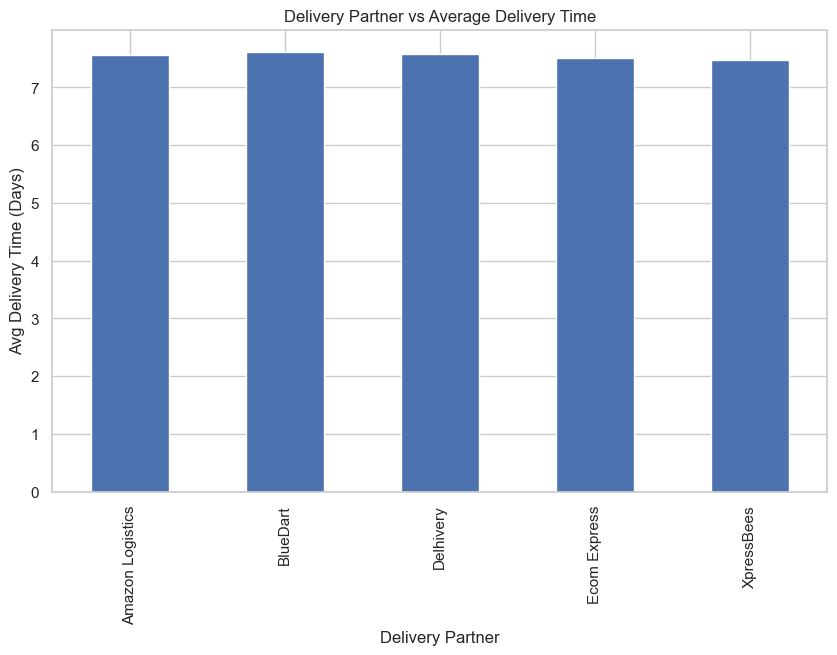

In [25]:
plt.figure(figsize=(10,6))
df.groupby('Delivery_Partner')['Delivery_Time_Days'].mean().plot(kind='bar')
plt.title("Delivery Partner vs Average Delivery Time")
plt.xlabel("Delivery Partner")
plt.ylabel("Avg Delivery Time (Days)")
plt.show()


### 📊 Insight:
Average delivery time varies across delivery partners, showing that partner performance directly affects delivery efficiency.


### Line Chart (Order Volume trend over time)

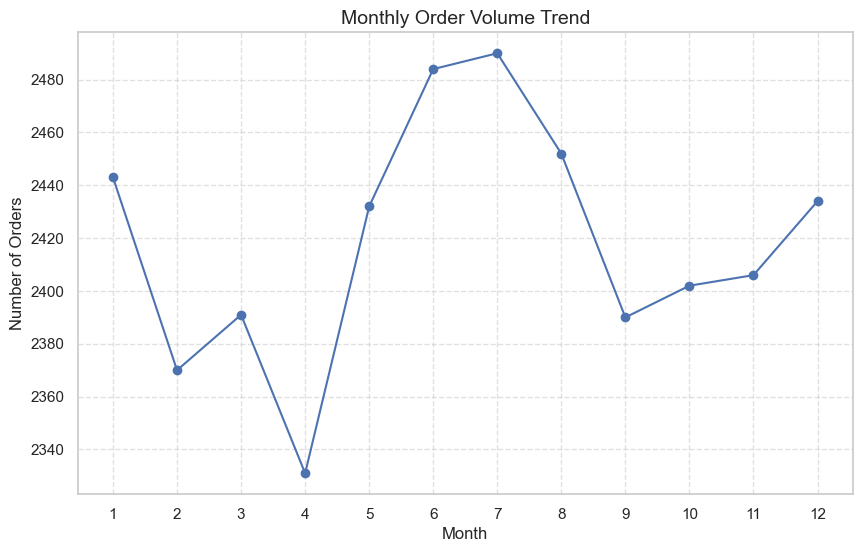

In [28]:
# Plot monthly order volume trend to observe changes in order frequency over time
plt.figure(figsize=(10, 6))

df.groupby(df['Order_Date'].dt.month).size().plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Order Volume Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


### 📊 Insight:
Order volume fluctuates across months, indicating seasonal trends in customer purchasing behavior.

### Histogram (Delivery time distribution )


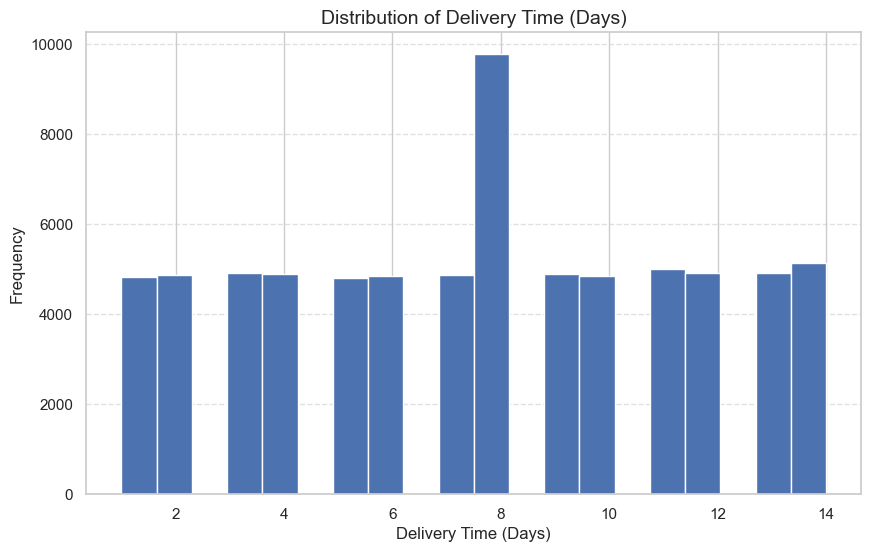

In [29]:
# Plot a histogram to understand the distribution of delivery time in days
plt.figure(figsize=(10, 6))

plt.hist(df['Delivery_Time_Days'], bins=20)

plt.title("Distribution of Delivery Time (Days)", fontsize=14)
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


### 📊 Insight:
Most deliveries are completed within a limited time range, while a few orders take longer, indicating occasional delays.

### Pie chart 

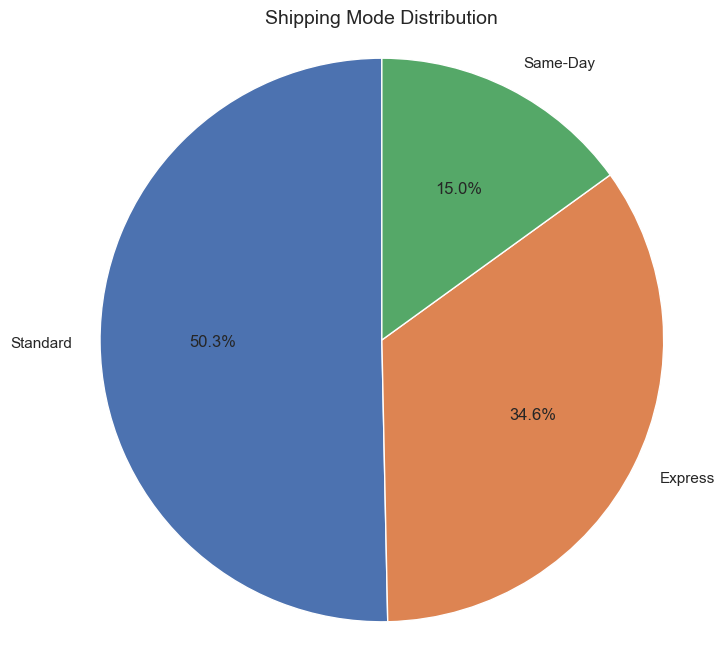

In [30]:
# Plot a pie chart to show the distribution of different shipping modes
plt.figure(figsize=(8, 8))

df['Shipping_Mode'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Shipping Mode Distribution", fontsize=14)
plt.ylabel("")  # Remove unnecessary y-axis label
plt.axis('equal')  # Ensures the pie chart is circular

plt.show()


### 📊 Insight:
Most orders are shipped using a few dominant shipping modes, indicating customer preference and operational focus on those modes.

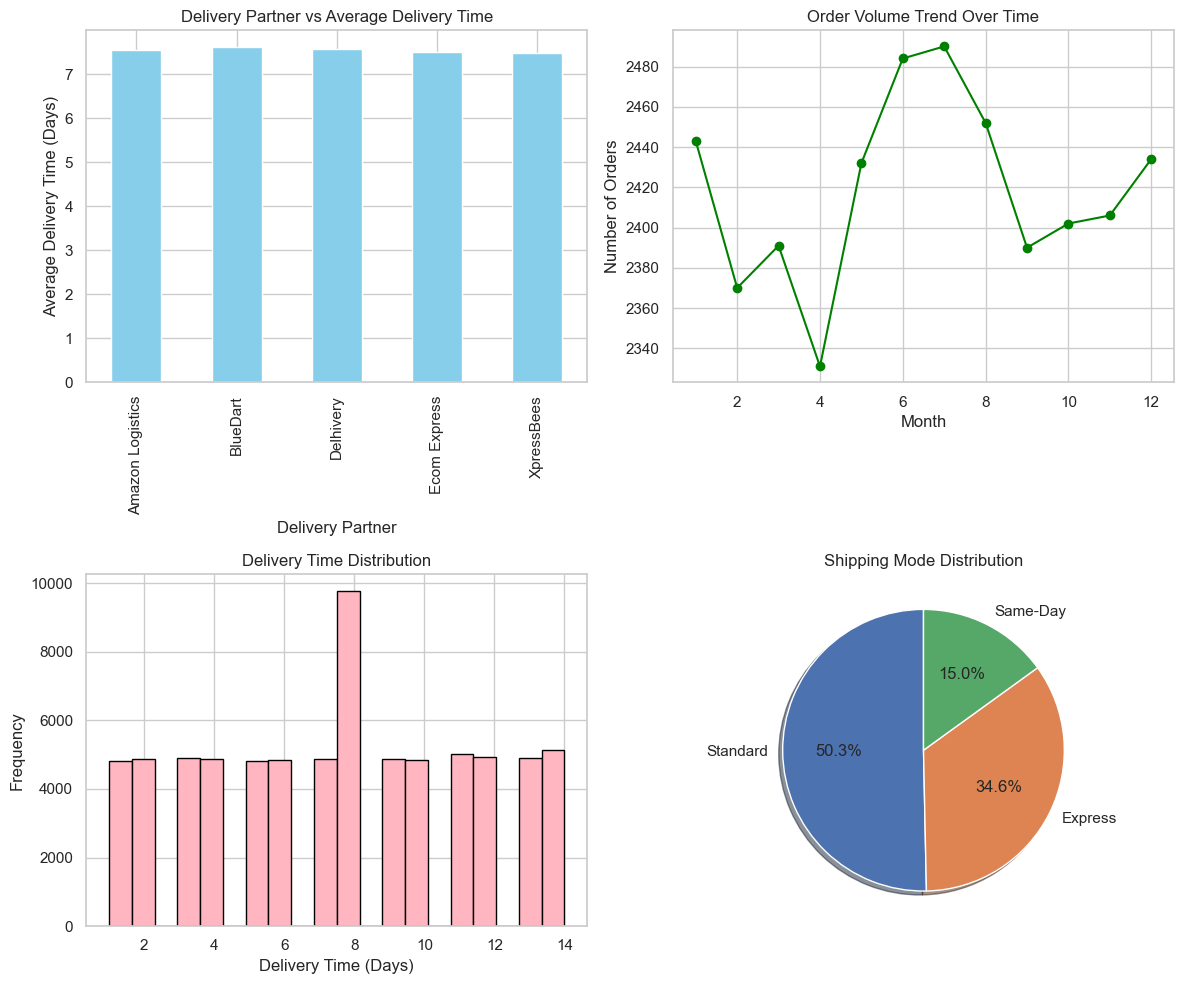

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

# 1. Delivery Partner vs Average Delivery Time
plt.subplot(2,2,1)
df.groupby('Delivery_Partner')['Delivery_Time_Days'].mean().plot(kind='bar', color='skyblue')
plt.title("Delivery Partner vs Average Delivery Time", fontsize=12)
plt.xlabel("Delivery Partner")
plt.ylabel("Average Delivery Time (Days)")

# 2. Order Volume Trend Over Time (Monthly)
plt.subplot(2,2,2)
df.groupby(df['Order_Date'].dt.month).size().plot(kind='line', marker='o', color='green')
plt.title("Order Volume Trend Over Time", fontsize=12)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)

# 3. Delivery Time Distribution
plt.subplot(2,2,3)
plt.hist(df['Delivery_Time_Days'], bins=20, color='lightpink', edgecolor='black')
plt.title("Delivery Time Distribution", fontsize=12)
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")

# 4. Shipping Mode Distribution
plt.subplot(2,2,4)
df['Shipping_Mode'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("Shipping Mode Distribution", fontsize=12)
plt.ylabel("")  # Remove the default y-label

plt.tight_layout()
plt.show()


# Task : 5 Final Insights & Task Completion 

## 🔍 Analysis Results

1. Faster deliveries lead to higher customer satisfaction.
2. High-priority orders are generally delivered faster.
3. Longer distances increase delivery time.
4. Efficient vehicle selection improves delivery performance.
5. Delays negatively impact customer ratings.
